In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [2]:
my_data = pd.read_csv(r"C:\Users\Child's Play\Documents\Datasets\SQL Assignment Attrition Table.csv")

In [3]:
my_data

,Age,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus,NumCompaniesWorked,YearsAtCompany,Unnamed: 9
0,41,Yes,Sales,Life Sciences,Female,Sales Executive,Single,8,6,NaN
1,49,No,Research & Development,Life Sciences,Male,Research Scientist,Married,1,10,NaN
2,37,Yes,Research & Development,Other,Male,Laboratory Technician,Single,6,0,NaN
3,33,No,Research & Development,Life Sciences,Female,Research Scientist,Married,1,8,NaN
4,27,No,Research & Development,Medical,Male,Laboratory Technician,Married,9,2,NaN
...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Research & Development,Medical,Male,Laboratory Technician,Married,4,5,NaN
1466,39,No,Research & Development,Medical,Male,Healthcare Representative,Married,4,7,NaN
1467,27,No,Research & Development,Life Sciences,Male,Manufacturing Director,Married,1,6,NaN
1468,49,No,Sales,Medical,Male,Sales Executive,Married,2,9,NaN


In [4]:
my_data = my_data.drop(['Unnamed: 9'], axis=1)

In [5]:
pd.set_option('display.float_format', lambda a: '%.0f' % a)

In [6]:
my_data.describe()

,Age,NumCompaniesWorked,YearsAtCompany
count,1470,1470,1470
mean,37,3,7
std,9,2,6
min,18,0,0
25%,30,1,3
50%,36,2,5
75%,43,4,9
max,60,9,40


In [7]:
my_data.corr(numeric_only=True)

,Age,NumCompaniesWorked,YearsAtCompany
Age,1,0,0
NumCompaniesWorked,0,1,-0
YearsAtCompany,0,-0,1


In [8]:
my_data.var(numeric_only=True)

Age                  83
NumCompaniesWorked    6
YearsAtCompany       38
dtype: float64

In [9]:
my_data.skew(numeric_only=True)

Age                  0
NumCompaniesWorked   1
YearsAtCompany       2
dtype: float64

In [10]:
my_data.describe(include='object')

,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus
count,1470,1470,1470,1470,1470,1470
unique,2,3,6,2,9,3
top,No,Research & Development,Life Sciences,Male,Sales Executive,Married
freq,1233,961,606,882,326,673


In [11]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 1470 non-null   int64 
 1   Attrition           1470 non-null   object
 2   Department          1470 non-null   object
 3   EducationField      1470 non-null   object
 4   Gender              1470 non-null   object
 5   JobRole             1470 non-null   object
 6   MaritalStatus       1470 non-null   object
 7   NumCompaniesWorked  1470 non-null   int64 
 8   YearsAtCompany      1470 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 103.5+ KB


In [12]:
my_data.isnull().sum()

Age                   0
Attrition             0
Department            0
EducationField        0
Gender                0
JobRole               0
MaritalStatus         0
NumCompaniesWorked    0
YearsAtCompany        0
dtype: int64

In [13]:
def imputed_method(data):
    for column in data.columns:
        if data[column].dtype in ['int64', 'float64'] and data[column].isnull().any():
            filler_strategy = SimpleImputer(strategy='most_frequent')
            data[column] = filler_strategy.fit_transform(data[[column]])
        else:
            data[column] = data[column].ffill()

imputed_method(my_data)

In [14]:
my_data.isnull().sum()

Age                   0
Attrition             0
Department            0
EducationField        0
Gender                0
JobRole               0
MaritalStatus         0
NumCompaniesWorked    0
YearsAtCompany        0
dtype: int64

In [15]:
my_data.loc[my_data.duplicated()]

,Age,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus,NumCompaniesWorked,YearsAtCompany
272,28,No,Research & Development,Medical,Male,Research Scientist,Married,1,5
326,39,No,Research & Development,Medical,Male,Manager,Married,1,21
515,35,No,Research & Development,Life Sciences,Male,Laboratory Technician,Married,1,1
640,24,No,Research & Development,Life Sciences,Male,Laboratory Technician,Married,0,5
718,45,No,Research & Development,Life Sciences,Male,Laboratory Technician,Married,1,9
991,32,No,Sales,Marketing,Male,Sales Executive,Married,0,3
1125,29,No,Research & Development,Life Sciences,Male,Healthcare Representative,Divorced,1,6
1134,35,No,Research & Development,Life Sciences,Male,Laboratory Technician,Married,1,1
1205,32,Yes,Research & Development,Life Sciences,Male,Laboratory Technician,Single,1,1
1300,34,No,Sales,Technical Degree,Male,Sales Executive,Married,1,10


In [16]:
my_data = my_data.drop_duplicates(ignore_index=True)

In [17]:
my_data

,Age,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus,NumCompaniesWorked,YearsAtCompany
0,41,Yes,Sales,Life Sciences,Female,Sales Executive,Single,8,6
1,49,No,Research & Development,Life Sciences,Male,Research Scientist,Married,1,10
2,37,Yes,Research & Development,Other,Male,Laboratory Technician,Single,6,0
3,33,No,Research & Development,Life Sciences,Female,Research Scientist,Married,1,8
4,27,No,Research & Development,Medical,Male,Laboratory Technician,Married,9,2
...,...,...,...,...,...,...,...,...,...
1452,36,No,Research & Development,Medical,Male,Laboratory Technician,Married,4,5
1453,39,No,Research & Development,Medical,Male,Healthcare Representative,Married,4,7
1454,27,No,Research & Development,Life Sciences,Male,Manufacturing Director,Married,1,6
1455,49,No,Sales,Medical,Male,Sales Executive,Married,2,9


In [18]:
my_data.dtypes

Age                    int64
Attrition             object
Department            object
EducationField        object
Gender                object
JobRole               object
MaritalStatus         object
NumCompaniesWorked     int64
YearsAtCompany         int64
dtype: object

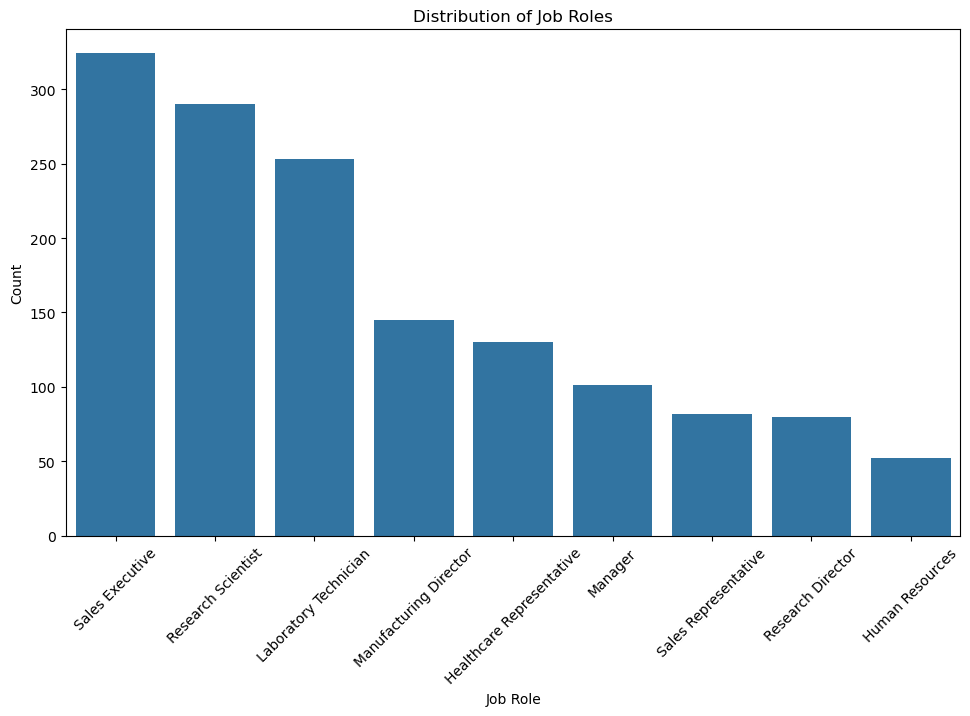

In [19]:
# plotting a count plot for a categorical variable; JobRole
order_method = my_data['JobRole'].value_counts().index
order_method
plt.figure(figsize=(10,6))
sns.countplot(data=my_data, x='JobRole', order=order_method)
plt.title('Distribution of Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

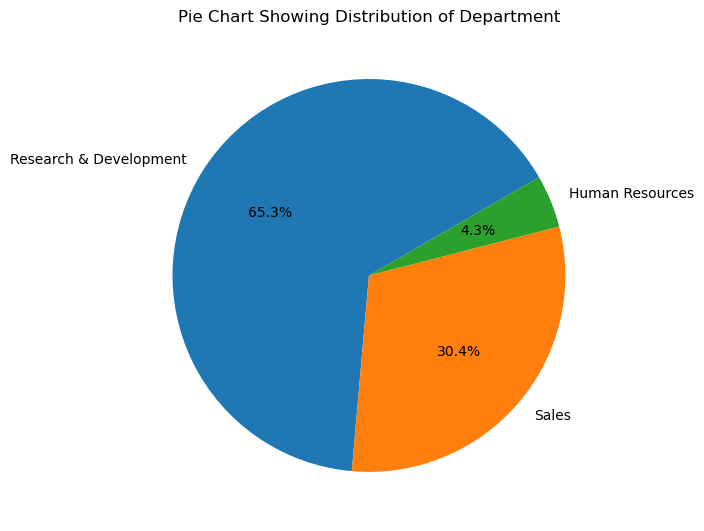

In [20]:
#plotting a pie chart to check the distribution 
plt.figure(figsize=(7,7))
my_data['Department'].value_counts().plot.pie(autopct='%1.1f%%', startangle=30)
plt.title('Pie Chart Showing Distribution of Department')
plt.ylabel('')
plt.tight_layout()
plt.show()

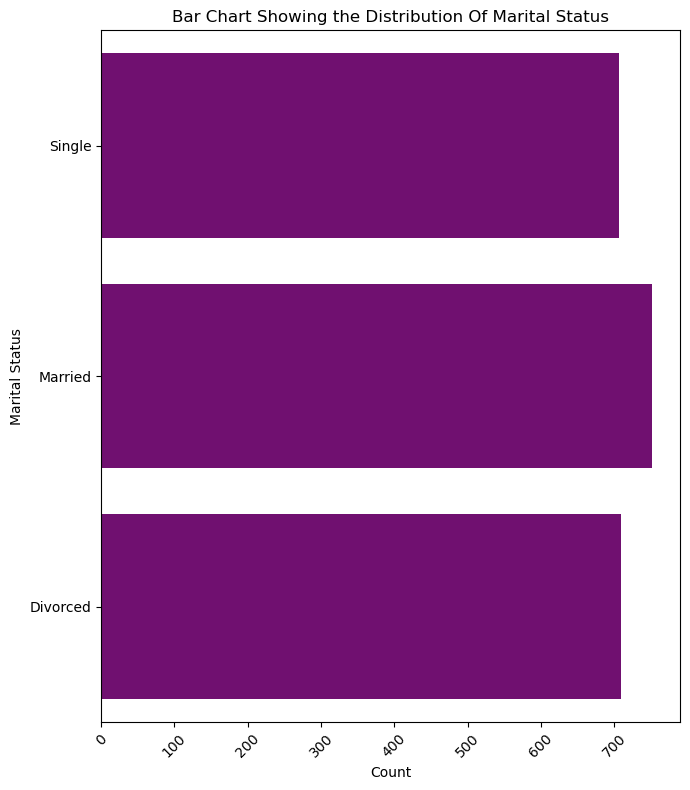

In [21]:

plt.figure(figsize=(7,8))
sns.barplot(data=my_data['MaritalStatus'], color='purple', errorbar=None)
plt.title('Bar Chart Showing the Distribution Of Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

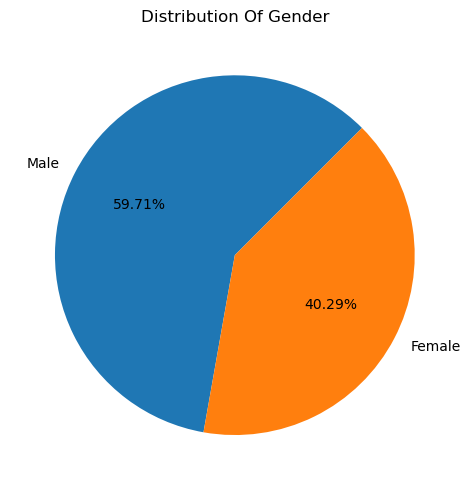

In [22]:
plt.figure(figsize=(8,5))
my_data['Gender'].value_counts().plot.pie(autopct='%1.2f%%', startangle=45)
plt.title('Distribution Of Gender')
plt.ylabel('')
plt.tight_layout()
plt.show()

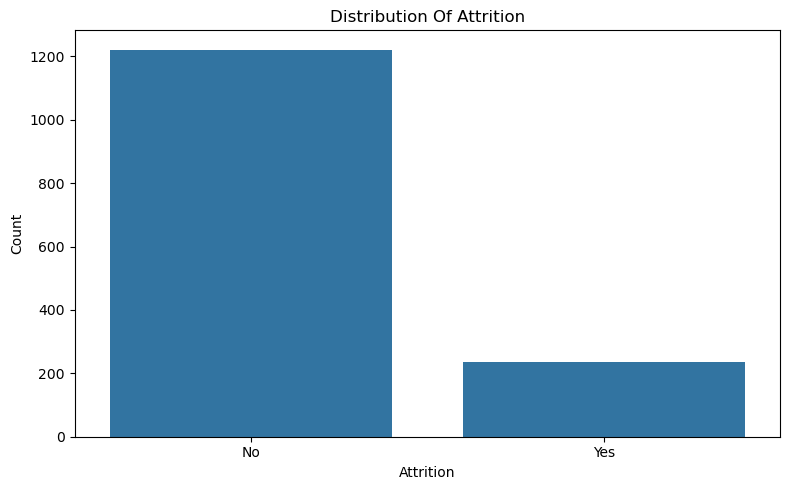

In [23]:
plt.figure(figsize=(8,5))
order_stuff = my_data['Attrition'].value_counts().index
sns.countplot(data=my_data, x='Attrition', order=order_stuff)
plt.title('Distribution Of Attrition')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

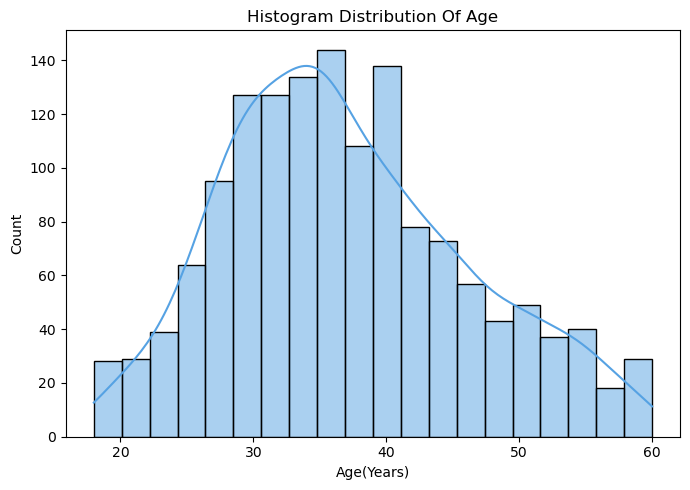

In [24]:
plt.figure(figsize=(7,5))
sns.histplot(data=my_data, x='Age', bins=20,color='#56A2E36B', kde=True)
plt.title('Histogram Distribution Of Age')
plt.xlabel('Age(Years)')
plt.tight_layout()
plt.show()

In [25]:
my_data.dtypes

Age                    int64
Attrition             object
Department            object
EducationField        object
Gender                object
JobRole               object
MaritalStatus         object
NumCompaniesWorked     int64
YearsAtCompany         int64
dtype: object

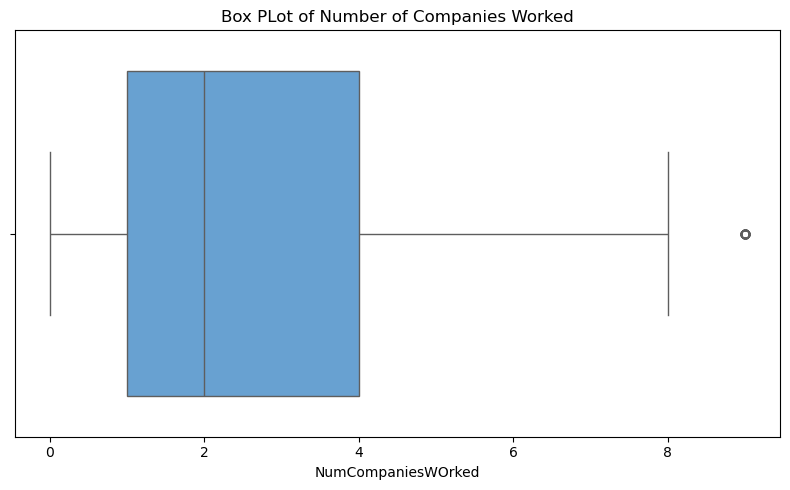

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=my_data, x='NumCompaniesWorked', color='#56A2E36B')
plt.title('Box PLot of Number of Companies Worked')
plt.xlabel('NumCompaniesWOrked')
plt.tight_layout()
plt.show()

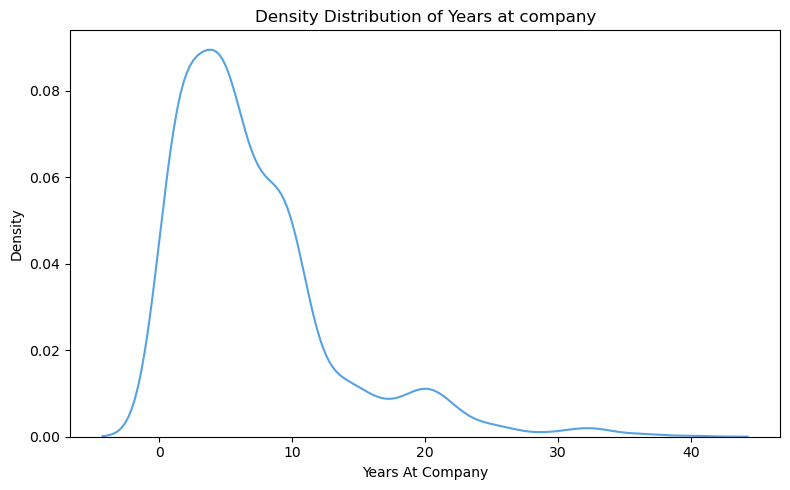

In [27]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=my_data['YearsAtCompany'], color='#56A2E36B')
plt.title('Density Distribution of Years at company')
plt.xlabel('Years At Company')
plt.tight_layout()
plt.show()

In [28]:
# my_data['YearsAtCompany'].skew()
my_data.skew(numeric_only=True)
# my_data['YearsAtCompany'].describe()

Age                  0
NumCompaniesWorked   1
YearsAtCompany       2
dtype: float64

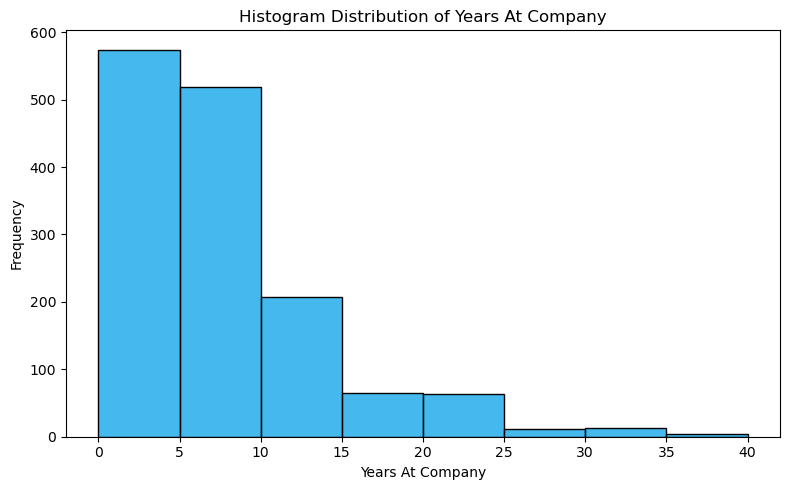

In [29]:

plt.figure(figsize=(8,5))
sns.histplot(data=my_data['YearsAtCompany'], bins=20, binwidth= 5, color='#06A2E76B')
plt.title('Histogram Distribution of Years At Company')
plt.xlabel('Years At Company')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [30]:
sns.set_style(style='dark')

### BIVARIATE ANALYSIS

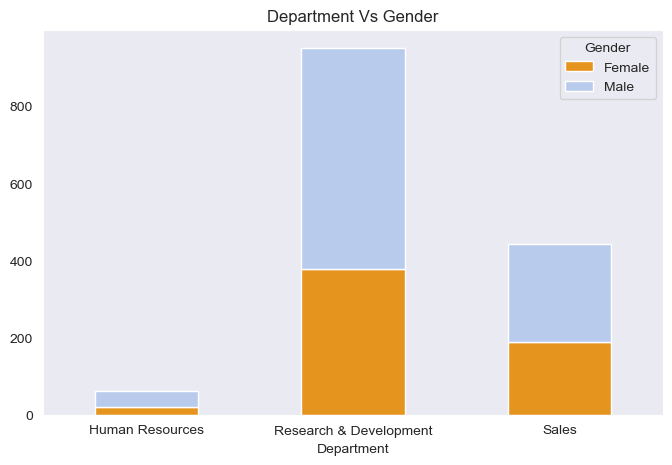

In [31]:
# plotting a stacked bar chart to showcase which gender is concentrated on each department
data_for_plot = pd.crosstab(my_data['Department'], my_data['Gender'])
data_for_plot.plot(kind='bar', stacked=True, color=['#e5941e', '#76A2E76B'], figsize=(8,5))
plt.title('Department vs gender'.title())
plt.xlabel('Department')
plt.legend(title='Gender')
plt.xticks(rotation=360)
plt.show()

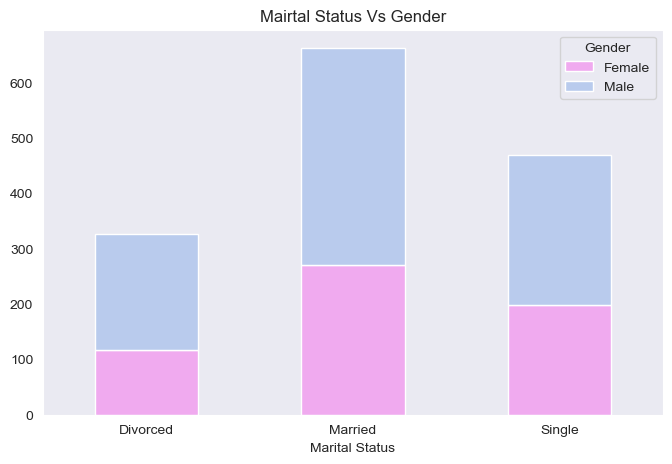

In [32]:
data_for_plot = pd.crosstab(my_data['MaritalStatus'], my_data['Gender'])
data_for_plot.plot(kind='bar', stacked=True, color=['#FF13E84B', '#76A2E76B'], figsize=(8,5))
plt.title('Mairtal Status vs gender'.title())
plt.xlabel('Marital Status')
plt.legend(title='Gender')
plt.xticks(rotation=360)
plt.show()

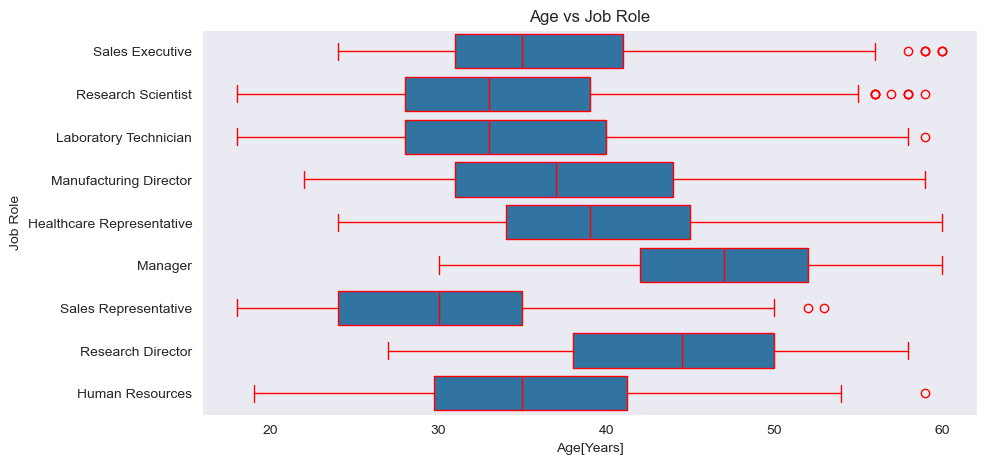

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(data=my_data, x='Age', y='JobRole', legend=False, linecolor='Red')
plt.title('Age vs Job Role')
plt.xlabel('Age[Years]')
plt.ylabel('Job Role')
plt.show()

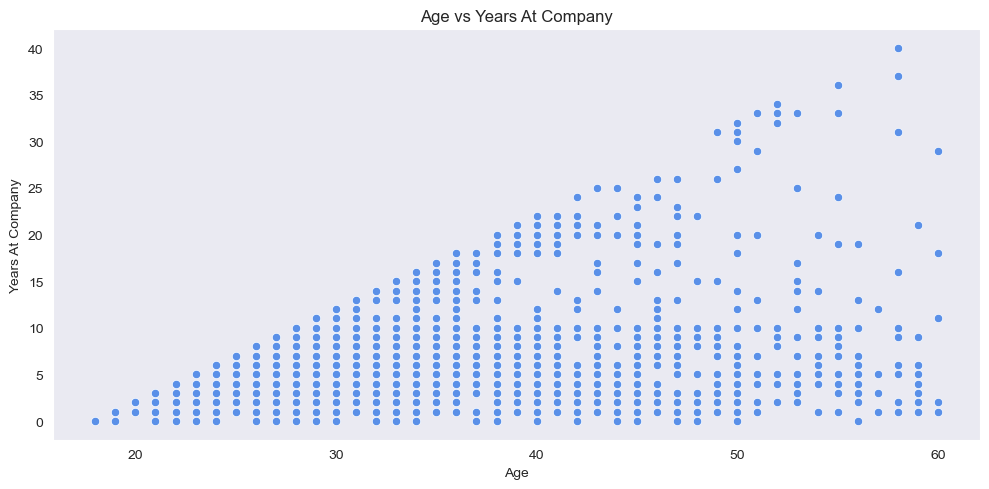

In [34]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=my_data, x='Age', y='YearsAtCompany', color='#5A90E80B', alpha=1)
plt.title('Age vs Years At Company')
plt.xlabel('Age')
plt.ylabel('Years At Company')
plt.tight_layout()
plt.show()

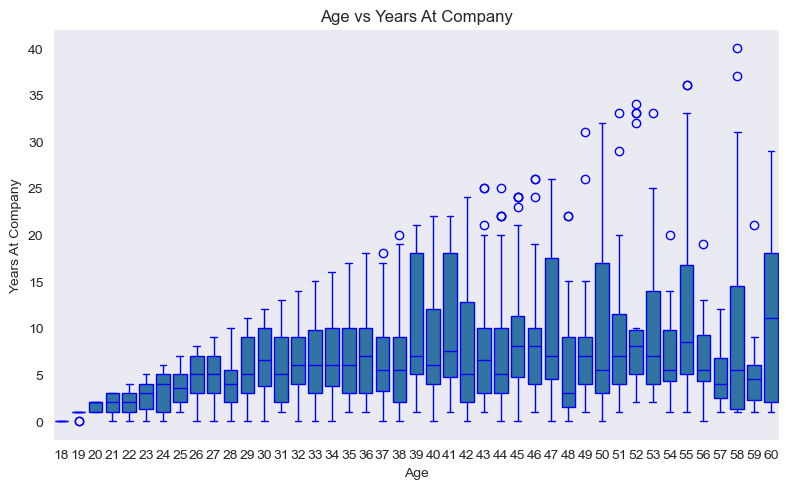

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(data=my_data, x='Age', y='YearsAtCompany', linecolor='Blue')
plt.title('Age vs Years At Company')
plt.xlabel('Age')
plt.ylabel('Years At Company')
plt.tight_layout()
plt.show()

C:\Users\Child's Play\AppData\Local\Temp\ipykernel_5732\3194258700.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=my_data, x='Age', y='YearsAtCompany', palette='viridis')


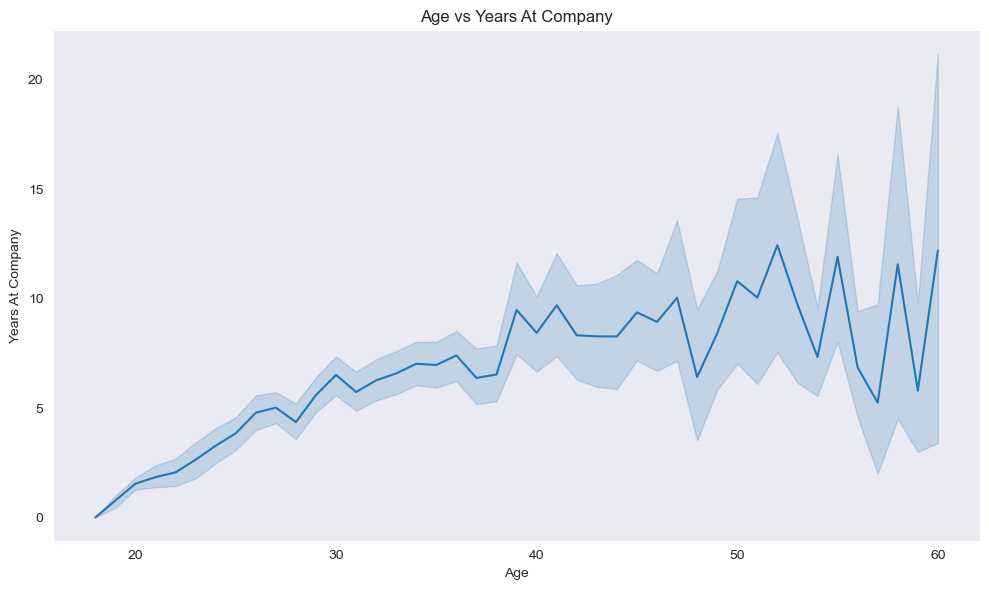

In [36]:
plt.figure(figsize=(10,6))
sns.lineplot(data=my_data, x='Age', y='YearsAtCompany', palette='viridis')
plt.title('Age vs Years At Company')
plt.xlabel('Age')
plt.ylabel('Years At Company')
plt.tight_layout()
plt.show()

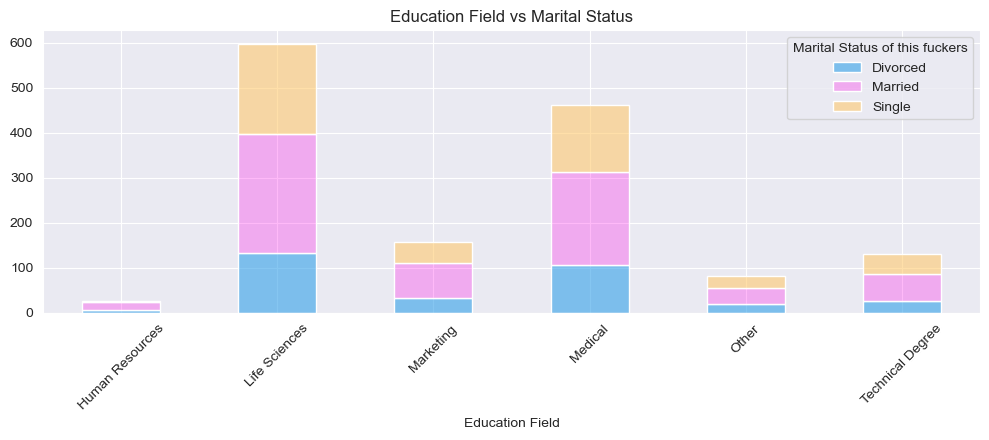

In [37]:
sns.set_style('darkgrid')
crossed_stuff = pd.crosstab(my_data['EducationField'], my_data['MaritalStatus'])
crossed_stuff.plot(kind='bar', stacked='True', color=['#36A2E99B', '#FF13E84B', '#FFC96E96'], figsize=(10,4.5))
plt.title('Education Field vs Marital Status')
plt.xlabel('Education Field')
plt.legend(title='Marital Status of this fuckers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
stacked_data = my_data.groupby('JobRole')['Attrition'].value_counts()

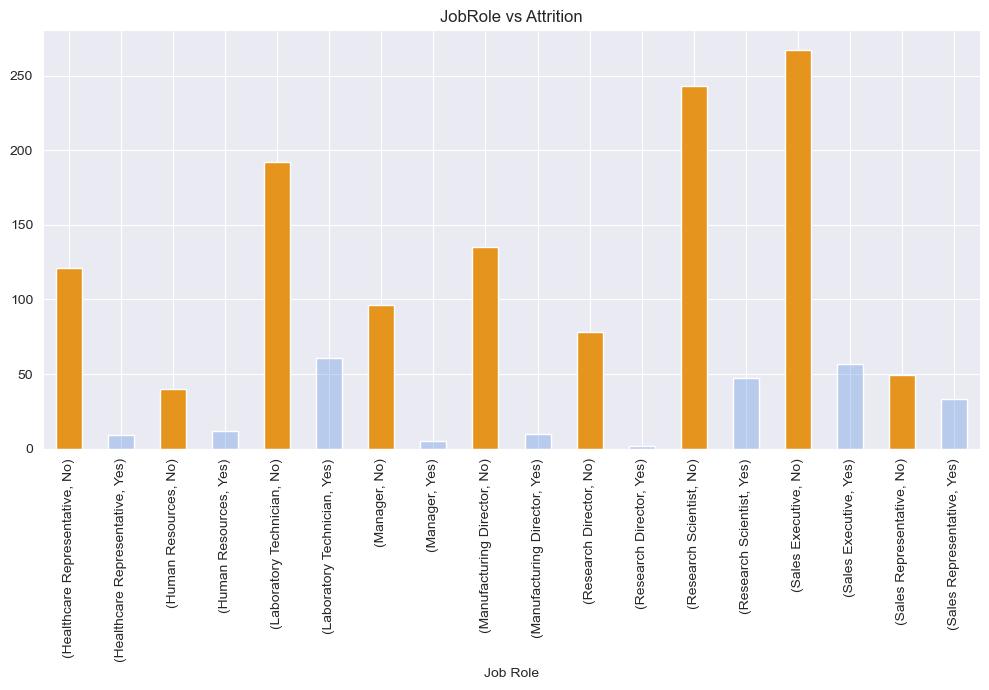

In [39]:
stacked_data.plot(kind='bar', stacked=True, color=['#e5941e', '#76A2E76B'], figsize=(10,7))
plt.title('JobRole vs Attrition')
plt.xlabel("Job Role")
plt.tight_layout()
plt.show()

In [40]:
crossed_stuff

MaritalStatus,Divorced,Married,Single
EducationField,,,
Human Resources,7,18,2
Life Sciences,133,265,200
Marketing,34,76,48
Medical,107,207,147
Other,19,36,27
Technical Degree,26,60,45


### MULTIVARIATE ANALYSIS



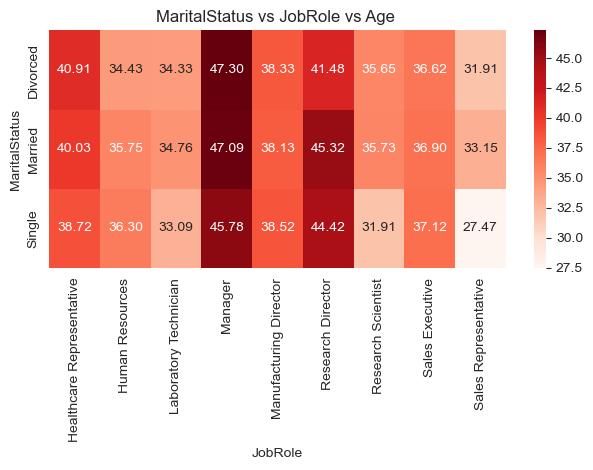

In [41]:
heated_tabled = my_data.groupby(['MaritalStatus', 'JobRole'])['Age'].mean().unstack()
sns.heatmap(heated_tabled, cmap='Reds', fmt='1.2f', annot=True)
plt.title('MaritalStatus vs JobRole vs Age ')
plt.tight_layout()
plt.show()

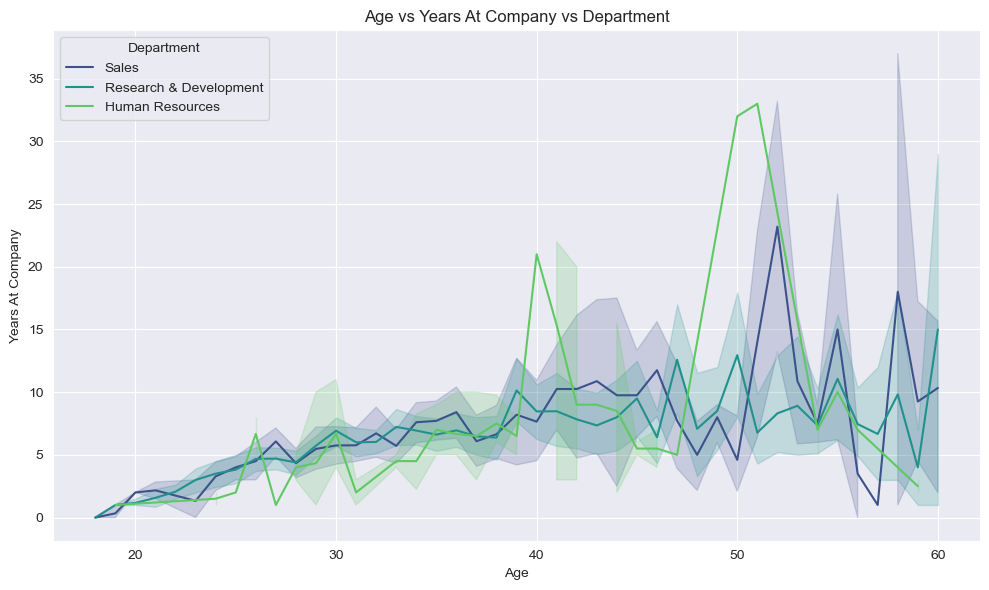

In [42]:
plt.figure(figsize=(10,6))
sns.lineplot(data=my_data, x='Age', y='YearsAtCompany', hue= 'Department', palette='viridis')
plt.title('Age vs Years At Company vs Department')
plt.xlabel('Age')
plt.ylabel('Years At Company')
plt.tight_layout()
plt.show()

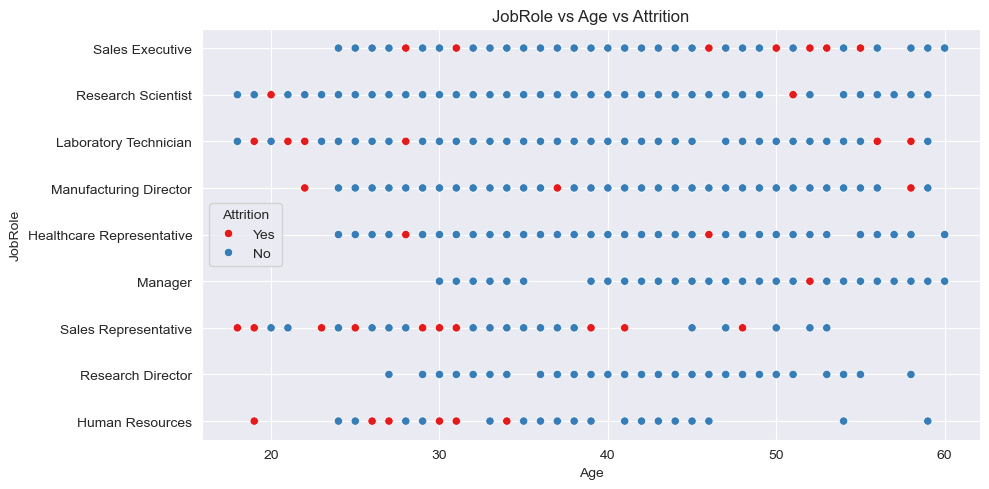

In [43]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=my_data, x='Age', y='JobRole', hue='Attrition', palette='Set1')
plt.title('JobRole vs Age vs Attrition')
plt.xlabel('Age')
plt.ylabel('JobRole')
plt.tight_layout()
plt.legend(title='Attrition')
plt.show()

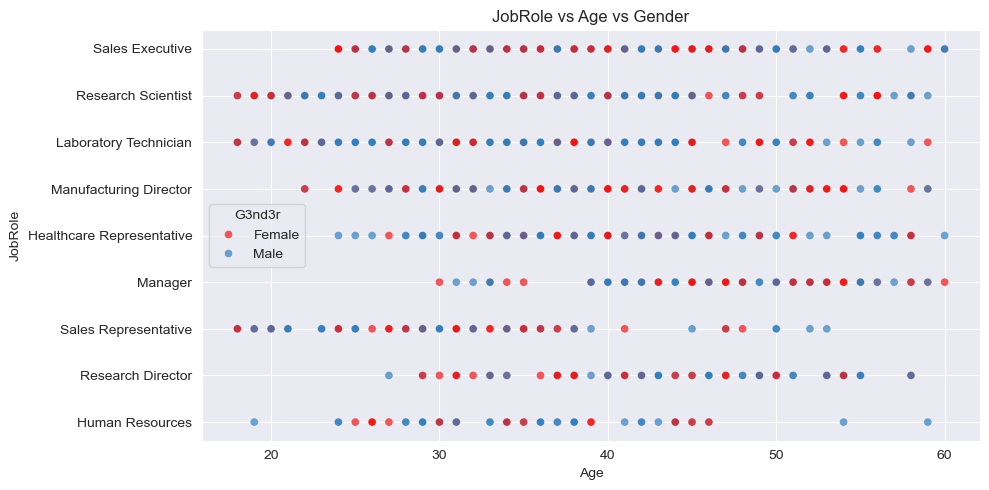

In [44]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=my_data, x='Age', y='JobRole', hue='Gender', palette='Set1', alpha=0.7)
plt.title('JobRole vs Age vs Gender')
plt.xlabel('Age')
plt.ylabel('JobRole')
plt.tight_layout()
plt.legend(title='G3nd3r')
plt.show()

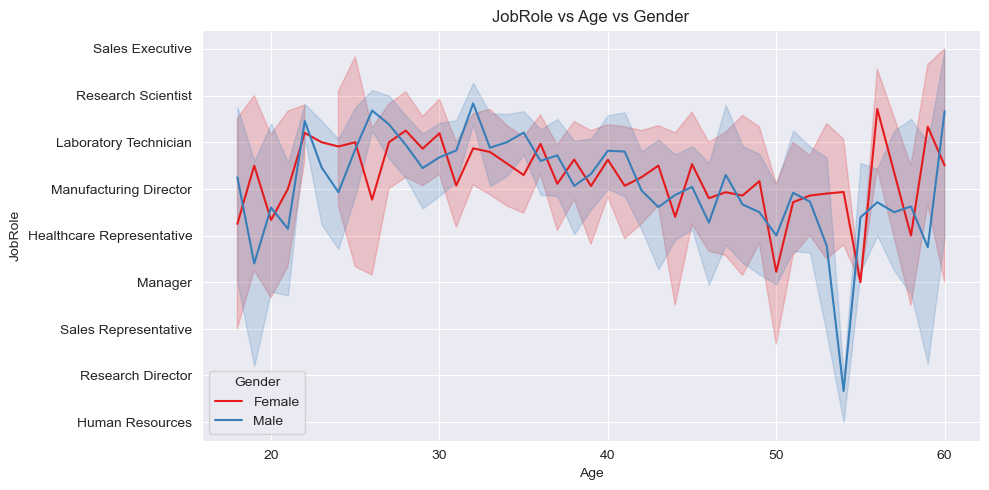

In [45]:
plt.figure(figsize=(10,5))
sns.lineplot(data=my_data, x='Age', y='JobRole', hue='Gender', palette='Set1')
plt.title('JobRole vs Age vs Gender')
plt.xlabel('Age')
plt.ylabel('JobRole')
plt.tight_layout()
plt.legend(title='Gender')
plt.show()

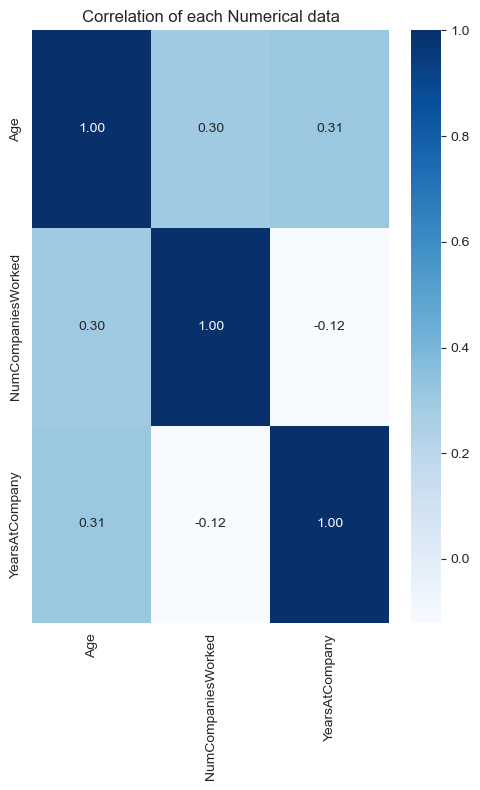

In [46]:
plt.figure(figsize=(5,8))
sns.heatmap(data=my_data.corr(numeric_only=True), annot=True, cmap='Blues', fmt='2.2f')
plt.title('Correlation of each Numerical data')
plt.tight_layout()
plt.show()

In [47]:
# sns.FacetGrid(data=my_data, row='Age', col='JobRole', hue='Gender', palette='Set2')
# plt.title('Bleh')
# plt.tight_layout()
# plt.show()

In [48]:
my_data.dtypes

Age                    int64
Attrition             object
Department            object
EducationField        object
Gender                object
JobRole               object
MaritalStatus         object
NumCompaniesWorked     int64
YearsAtCompany         int64
dtype: object

In [49]:
my_data.groupby('JobRole')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
JobRole,,,,,,,,
Healthcare Representative,130,40,8,24,34,39,45,60
Human Resources,52,36,8,19,30,35,41,59
Laboratory Technician,253,34,8,18,28,33,40,59
Manager,101,47,7,30,42,47,52,60
Manufacturing Director,145,38,9,22,31,37,44,59
Research Director,80,44,8,27,38,44,50,58
Research Scientist,290,34,9,18,28,33,39,59
Sales Executive,324,37,8,24,31,35,41,60
Sales Representative,82,30,9,18,24,30,35,53


In [50]:
my_data.groupby('JobRole')['Age'].skew()

JobRole
Healthcare Representative    1
Human Resources              1
Laboratory Technician        1
Manager                     -0
Manufacturing Director       1
Research Director           -0
Research Scientist           1
Sales Executive              1
Sales Representative         1
Name: Age, dtype: float64

In [51]:
my_data.dtypes

Age                    int64
Attrition             object
Department            object
EducationField        object
Gender                object
JobRole               object
MaritalStatus         object
NumCompaniesWorked     int64
YearsAtCompany         int64
dtype: object

In [52]:
cross_table = pd.crosstab(my_data['Department'], my_data['Gender'])
cross_table

Gender,Female,Male
Department,,
Human Resources,20,43
Research & Development,378,573
Sales,189,254


In [53]:
# my_data.groupby('YearsAtCompany').agg(['count'])

In [54]:
# my_data['NumCompaniesWorked'].describe()

In [55]:
# my_iqr = 4 - 1
# max_limit = 4 + 1.5 * my_iqr
# my_data.loc[my_data['NumCompaniesWorked']>max_limit]

### STATISTICAL INSIGHTS

In [56]:
from scipy import stats

In [57]:
my_data.head()

,Age,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus,NumCompaniesWorked,YearsAtCompany
0,41,Yes,Sales,Life Sciences,Female,Sales Executive,Single,8,6
1,49,No,Research & Development,Life Sciences,Male,Research Scientist,Married,1,10
2,37,Yes,Research & Development,Other,Male,Laboratory Technician,Single,6,0
3,33,No,Research & Development,Life Sciences,Female,Research Scientist,Married,1,8
4,27,No,Research & Development,Medical,Male,Laboratory Technician,Married,9,2


In [58]:
my_data['NumCompaniesWorked'].corr(my_data.YearsAtCompany)

np.float64(-0.12142239821843244)

In [59]:
my_data.head(3)

,Age,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus,NumCompaniesWorked,YearsAtCompany
0,41,Yes,Sales,Life Sciences,Female,Sales Executive,Single,8,6
1,49,No,Research & Development,Life Sciences,Male,Research Scientist,Married,1,10
2,37,Yes,Research & Development,Other,Male,Laboratory Technician,Single,6,0


In [60]:
my_data['Attrition']= my_data['Attrition']\
        .str.strip()\
        .str.title()\
        .map({'Yes':1, 'No':0})
my_data['Attrition'].head(5)

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [61]:
my_data.head()

,Age,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus,NumCompaniesWorked,YearsAtCompany
0,41,1,Sales,Life Sciences,Female,Sales Executive,Single,8,6
1,49,0,Research & Development,Life Sciences,Male,Research Scientist,Married,1,10
2,37,1,Research & Development,Other,Male,Laboratory Technician,Single,6,0
3,33,0,Research & Development,Life Sciences,Female,Research Scientist,Married,1,8
4,27,0,Research & Development,Medical,Male,Laboratory Technician,Married,9,2


In [62]:
my_data['Attrition'].mean().round(3) * 100

np.float64(16.2)

In [63]:
my_data.groupby('MaritalStatus')['Attrition'].mean().round(3) * 100

MaritalStatus
Divorced   10
Married    13
Single     25
Name: Attrition, dtype: float64

In [64]:
# we want to know the job role where people leave the most. so we group mean attrition by job role 
my_data.groupby('JobRole').Attrition.mean().idxmax()

'Sales Representative'

In [65]:
# the code below is for knowing how many year people stay at company before leaving.
my_data[my_data.Attrition==1]['YearsAtCompany'].mode()[0]

np.int64(1)

In [66]:
opupu = my_data[my_data.Attrition == 1]['YearsAtCompany']
print("Most common exit year =", opupu.mode()[0])

print("How many quit in Year 1 =", (opupu == 1).sum(), "out of", len(opupu))
print("% who quit in year 1 =", round(100*(opupu == 1).mean(), 1), "%")

Most common exit year = 1
How many quit in Year 1 = 58 out of 236
% who quit in year 1 = 24.6 %


In [67]:
(my_data.YearsAtCompany >=9).mean().round(3) * 100

np.float64(30.5)

In [68]:
stay_at_comp = my_data[my_data.YearsAtCompany >=9]
print('Employees with 9+ years is:', len(stay_at_comp))
print('How many of them left:', stay_at_comp.Attrition.sum())
print('Stay rate =', round(100*(1-stay_at_comp.Attrition.mean()), 1), "%")

Employees with 9+ years is: 445
How many of them left: 46
Stay rate = 89.7 %


In [69]:
my_data.assign(age_divide=pd.cut(my_data.Age, bins=range(15,65,5)))\
        .groupby('age_divide').Attrition.mean().idxmin()

C:\Users\Child's Play\AppData\Local\Temp\ipykernel_5732\4086968808.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_divide').Attrition.mean().idxmin()


Interval(35, 40, closed='right')

In [70]:
safe = my_data[my_data.Age>35][my_data.Age <= 40]

print("35-40 year-olds =", len(safe), "employees")
print("Left =", safe.Attrition.sum())
print("Stay rate =", round(100*(1-safe.Attrition.mean()), 1), "%")

35-40 year-olds = 275 employees
Left = 25
Stay rate = 90.9 %


C:\Users\Child's Play\AppData\Local\Temp\ipykernel_5732\2272606662.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  safe = my_data[my_data.Age>35][my_data.Age <= 40]


### STATISTICAL TEST
* we are conducting three statistical practices on our dataset
* 1. Who leaves the most?
  2. Is it real or luck
  3. how worse it is?

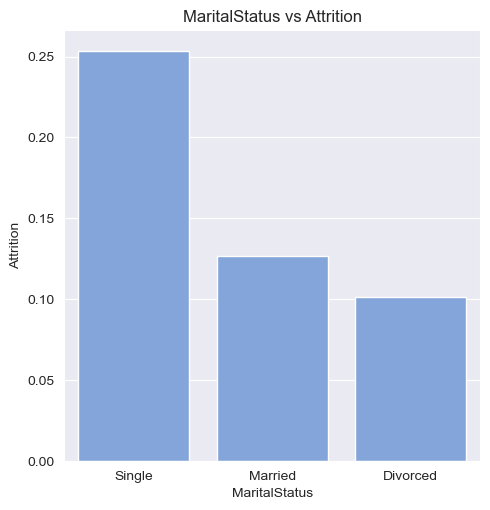

In [71]:
plt.figure(figsize=(5,5))
sns.barplot(data=my_data, x='MaritalStatus', y='Attrition', color= '#76A2E76B', errorbar=None)
plt.tight_layout()
plt.title('MaritalStatus vs Attrition')
plt.show()

## Chi-Square Test

In [72]:
my_data['HighRisk'] = ((my_data['MaritalStatus'] == 'Single') & 
                      (my_data['JobRole'] == 'Sales Representative') &
                      (my_data['Age'] < 30)).astype(int)

In [73]:
our_tab = pd.crosstab(my_data['HighRisk'], my_data['Attrition'])
chi2, p, dof, exp = stats.chi2_contingency(our_tab)
effect = np.sqrt(chi2 / my_data.shape[0]) # this is the formula for cramer's V and it shows the effect of people
# leaving and if it is big or small.

In [74]:
print(effect)

0.14608425398750363


In [75]:
max_rate = my_data.groupby('HighRisk').Attrition.mean().max()
min_rate = my_data.groupby('HighRisk').Attrition.mean().min()
gap = max_rate - min_rate
print(f"Singles vs MArried: {gap:.1%} gap")
print(f"p = {p:.2e} | effect = {effect:.2f} Real & Big")

Singles vs MArried: 45.4% gap
p = 2.46e-08 | effect = 0.15 Real & Big


In [76]:
n = our_tab.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(our_tab.shape)-1)))

In [77]:
print(f'Cramer"s V = {cramers_v:.3f}')

Cramer"s V = 0.146


## MANN-WHITNEY

In [78]:
high = my_data[my_data['HighRisk']==1]['YearsAtCompany']
low = my_data[my_data['HighRisk']==0]['YearsAtCompany']
u, p_mw = stats.mannwhitneyu(high, low, alternative='less')
print(f"Mann-Whitney p = {p_mw:.2e}")

Mann-Whitney p = 3.31e-09


# LOGISTIC REGRESSION

In [79]:
import statsmodels.formula.api as smf

In [80]:
from sklearn.tree import DecisionTreeClassifier

In [81]:
model = smf.logit('Attrition ~ HighRisk + Age + C(JobRole)', data=my_data).fit(disp=0)
print(model.summary().tables[1])

                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -1.6014      0.504     -3.178      0.001      -2.589      -0.614
C(JobRole)[T.Human Resources]            1.2901      0.480      2.690      0.007       0.350       2.230
C(JobRole)[T.Laboratory Technician]      1.3104      0.380      3.453      0.001       0.567       2.054
C(JobRole)[T.Manager]                   -0.1755      0.579     -0.303      0.762      -1.310       0.959
C(JobRole)[T.Manufacturing Director]    -0.0467      0.477     -0.098      0.922      -0.982       0.888
C(JobRole)[T.Research Director]         -0.9618      0.797     -1.207      0.227      -2.523       0.599
C(JobRole)[T.Research Scientist]         0.8152      0.385      2.120      0.034       0.061       1.569
C(JobRole)[T.Sales Executive]            0.9830      0.

* If coef is positive and p<0.05 = more likely to quit
* if coef is negative and p<0.05 = less likely to quit
* if p>0.05 = not a problem
* use the np.exp() and pass in the coef to find the odd multiplier
* if Z > 3 = very strong
* if Z < 2 = strong

## DECISION TREE


In [82]:
x = pd.get_dummies(my_data[['Age', 'MaritalStatus', 'JobRole']], drop_first=True)
y = my_data['Attrition']
tree = DecisionTreeClassifier(max_depth=2, random_state=42).fit(x,y)
print('Top Splits:', tree.feature_importances_)

Top Splits: [0.47033317 0.         0.45674489 0.         0.         0.
 0.         0.         0.         0.07292194 0.        ]


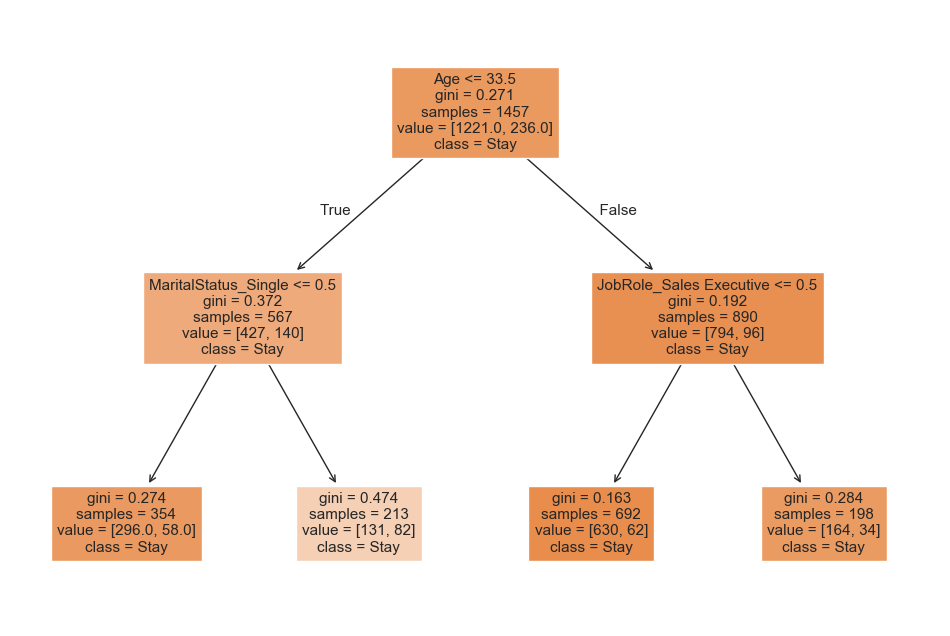

In [83]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=x.columns, class_names=['Stay', 'Quit'], filled=True)
plt.show()